In [2]:
from typing import Dict, Set, Tuple, List, Any
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict
from pprint import pprint

PROJECT_ROOT = Path('../..').resolve()  # Adjust as needed to find the project root
DOXYGEN_XML_DIR = PROJECT_ROOT / ".ai/context/doxygen_output/xml"

In [3]:
refid_tags = set()

for xml_file in DOXYGEN_XML_DIR.glob("*.xml"):
    if xml_file.name == "index.xml":
        continue

    tree = ET.parse(xml_file)
    for elem in tree.iter():
        if 'refid' in elem.attrib:
            refid_tags.add(elem.tag)
    
print(refid_tags)

{'reimplementedby', 'innerclass', 'member', 'reimplements', 'derivedcompoundref', 'link', 'innernamespace', 'includedby', 'includes', 'referencedby', 'references', 'ref', 'innerfile', 'codeline', 'innerdir', 'basecompoundref', 'childnode'}


In [17]:
# extract the full 'compounddef' structure from the XML files
root_structure = {}
paths = set()

path_qualifiers: Dict[str, List[str]] = {
    'compounddef': ['kind'],
    'memberdef': ['kind'],
}
path_qualifier_values: Dict[Tuple[str, str], Set[Any]] = {}
stop_tags = set([
#    'programlisting',
    'collaborationgraph',
    'inheritancegraph',
    'listofallmembers',
    'invincdepgraph',
    'incdepgraph',
])

def recursive_merge(d1: Dict[str, Any], d2: Dict[str, Any]):
    for k, v in d2.items():
        if k in d1 and type(d1[k]) != type(v):
            raise ValueError(f"Type mismatch for key '{k}': {type(d1[k])} vs {type(v)}")
        if k in d1 and isinstance(d1[k], dict) and isinstance(v, dict):
            recursive_merge(d1[k], v)
        else:
            d1[k] = v

def document_element(elem: ET.Element, path: List[str] = []) -> Dict[str, Any]:
    if elem.tag in stop_tags:
        return {}
    d = {k:type(v).__name__ for k, v in elem.attrib.items()}

    tag = elem.tag
    if tag in path_qualifiers:
        for a in path_qualifiers[tag]:
            path_qualifier_values.setdefault((tag, a), set()).add(elem.attrib.get(a, None))
        tag += f"[{','.join(f'{a}={str(elem.attrib.get(a))}' for a in path_qualifiers[tag])}]"
    path = path + [tag]
    d['_path'] = '|'.join(path)
    paths.add(tuple(path))

    if len(elem):
        for child in elem:
            recursive_merge(d.setdefault('tags', {}).setdefault(child.tag, {}), document_element(child, path))
    return d

for xml_file in DOXYGEN_XML_DIR.glob("*.xml"):
    if xml_file.name == "index.xml":
        continue

    tree = ET.parse(xml_file)
    root = tree.getroot().find('.//compounddef')
    if root is None:
        continue

    recursive_merge(root_structure, document_element(root))

In [18]:
seen_references = set()
path_strings = set()

for path in paths:
    if path[-1] not in refid_tags:
        continue
    seen_references.add(path[-1])
    path_strings.add('|'.join(n for n in path))

print(seen_references)
for p in sorted(path_strings):
    print(p)

{'reimplementedby', 'innerclass', 'member', 'reimplements', 'derivedcompoundref', 'includedby', 'innernamespace', 'includes', 'referencedby', 'references', 'innerfile', 'codeline', 'innerdir', 'basecompoundref', 'ref'}
compounddef[kind=class]|basecompoundref
compounddef[kind=class]|derivedcompoundref
compounddef[kind=class]|includes
compounddef[kind=class]|innerclass
compounddef[kind=class]|sectiondef|memberdef[kind=friend]|param|type|ref
compounddef[kind=class]|sectiondef|memberdef[kind=function]|briefdescription|para|ref
compounddef[kind=class]|sectiondef|memberdef[kind=function]|param|type|ref
compounddef[kind=class]|sectiondef|memberdef[kind=function]|referencedby
compounddef[kind=class]|sectiondef|memberdef[kind=function]|references
compounddef[kind=class]|sectiondef|memberdef[kind=function]|reimplementedby
compounddef[kind=class]|sectiondef|memberdef[kind=function]|reimplements
compounddef[kind=class]|sectiondef|memberdef[kind=function]|type|ref
compounddef[kind=class]|sectiondef

In [10]:
from collections import defaultdict
import re

# Group reference paths by pattern to identify reference types
reference_paths = [p for p in path_strings if any(tag in p for tag in refid_tags)]

# Define meaningful categories for references based on path patterns
reference_categories = {
    'inheritance': ['inheritedby', 'basecompoundref', 'derivedcompoundref'],
    'member_of': ['innerclass', 'innernamespace', 'innerdir', 'innerfile', 'innerstruct', 'innergroup', 'innerunion'],
    'usage': ['references', 'referencedby'],
    'includes': ['includes', 'includedby'],
    'function_relations': ['param', 'reimplements', 'reimplementedby'],
    'type_relations': ['templateparamlist', 'ref']
}

# Stats counters
ref_stats = defaultdict(int)
categorized_refs = defaultdict(list)
uncategorized = []

# Process each reference path
for path in reference_paths:
    path_segments = path.split('|')
    
    # Extract the actual reference tag (last segment with refid)
    ref_tag = next((seg for seg in reversed(path_segments) if seg in refid_tags), None)
    if not ref_tag:
        continue
        
    # Try to categorize based on the tag name
    categorized = False
    for category, patterns in reference_categories.items():
        if any(pattern in ref_tag for pattern in patterns):
            categorized_refs[category].append(path)
            ref_stats[ref_tag] += 1
            categorized = True
            break
            
    # If tag name didn't match, try to categorize based on context
    if not categorized:
        context = '|'.join(path_segments[:-1])  # Everything before the ref tag
        
        # Examples of context-based categorization
        if 'location' in context:
            categorized_refs['location_refs'].append(path)
            ref_stats[ref_tag] += 1
        elif 'initializer' in context:
            categorized_refs['initialization'].append(path)
            ref_stats[ref_tag] += 1
        elif 'detaileddescription' in context:
            categorized_refs['documentation'].append(path)
            ref_stats[ref_tag] += 1
        else:
            uncategorized.append(path)
            ref_stats[ref_tag] += 1

# Print statistics and categorized references
print("=== Reference Tag Distribution ===")
for tag, count in sorted(ref_stats.items(), key=lambda x: x[1], reverse=True):
    print(f"{tag}: {count} occurrences")

print("\n=== References by Category ===")
for category, paths in sorted(categorized_refs.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"\n{category.upper()} ({len(paths)} references):")
    # Show a few examples from each category
    for path in sorted(paths)[:5]:
        print(f"  - {path}")
    if len(paths) > 5:
        print(f"  ... and {len(paths)-5} more")

if uncategorized:
    print(f"\nUNCATEGORIZED ({len(uncategorized)} references):")
    for path in sorted(uncategorized)[:5]:
        print(f"  - {path}")
    if len(uncategorized) > 5:
        print(f"  ... and {len(uncategorized)-5} more")

=== Reference Tag Distribution ===
ref: 35 occurrences
referencedby: 11 occurrences
references: 4 occurrences
innerclass: 3 occurrences
includes: 3 occurrences
reimplements: 2 occurrences
basecompoundref: 2 occurrences
member: 2 occurrences
reimplementedby: 2 occurrences
derivedcompoundref: 2 occurrences
codeline: 1 occurrences
innernamespace: 1 occurrences
includedby: 1 occurrences
innerfile: 1 occurrences
innerdir: 1 occurrences

=== References by Category ===

TYPE_RELATIONS (35 references):
  - compounddef[kind=class]|sectiondef|memberdef[kind=friend]|param|type|ref
  - compounddef[kind=class]|sectiondef|memberdef[kind=function]|briefdescription|para|ref
  - compounddef[kind=class]|sectiondef|memberdef[kind=function]|param|type|ref
  - compounddef[kind=class]|sectiondef|memberdef[kind=function]|type|ref
  - compounddef[kind=class]|sectiondef|memberdef[kind=variable]|briefdescription|para|ref
  ... and 30 more

USAGE (15 references):
  - compounddef[kind=class]|sectiondef|memberdef[

In [11]:
import pandas as pd

# Create a summary DataFrame of most important reference types
reference_summary = {
    'Type': [],
    'Count': [],
    'Description': [],
    'Structural Value': [],  # On a scale of 1-5, how valuable for structural understanding
    'Usage Value': []        # On a scale of 1-5, how valuable for usage understanding
}

# Add key reference types with descriptions and value scores
key_references = [
    ('references', 'Direct references to other entities (function calls, variable uses)', 5, 5),
    ('referencedby', 'Entities that reference this entity (inverse of references)', 5, 5),
    ('basecompoundref', 'Base class of this class (inheritance relationship)', 5, 3),
    ('derivedcompoundref', 'Classes that derive from this class', 4, 2),
    ('includes', 'Header files included by this file', 3, 4),
    ('includedby', 'Files that include this file', 3, 4),
    ('innerclass', 'Classes defined within this compound', 4, 3),
    ('innernamespace', 'Namespaces defined within this namespace', 4, 2),
    ('param', 'Function parameters', 2, 3),
    ('ref', 'General cross-reference (often in documentation)', 1, 2)
]

# Populate the summary with actual counts from the analysis output
for ref_type, description, struct_val, usage_val in key_references:
    count = ref_stats.get(ref_type, 0)
    reference_summary['Type'].append(ref_type)
    reference_summary['Count'].append(count)
    reference_summary['Description'].append(description)
    reference_summary['Structural Value'].append(struct_val)
    reference_summary['Usage Value'].append(usage_val)

# Create and display the DataFrame
reference_df = pd.DataFrame(reference_summary)
reference_df = reference_df.sort_values(by=['Structural Value', 'Usage Value', 'Count'], ascending=False)
reference_df

# Provide recommendations based on findings
print("\n=== Recommendations for Graph Construction ===")
print("Based on the analysis of Doxygen reference types, we recommend the following edge types for the code graph:")
print("\n1. CALLS: Direct function calls (from 'references' between functions)")
print("   - High value for both structural and usage understanding")
print("   - Represents runtime behavior")
print("\n2. USES: Symbol usage beyond function calls (from 'references' for variables, types)")
print("   - Important for identifying implementation dependencies")
print("\n3. INHERITS: Inheritance relationships (from 'basecompoundref'/'derivedcompoundref')")
print("   - Essential for understanding class hierarchies")
print("   - Key structural information")
print("\n4. INCLUDES: File inclusion relationships (from 'includes'/'includedby')")
print("   - Important for compilation dependencies")
print("\n5. CONTAINS: Containment relationships (from 'innerclass', 'innernamespace')")
print("   - Represents hierarchical code organization")
print("\nIntroducing these distinct edge types would provide more granular and meaningful clustering compared to")
print("the current single 'required_by' relationship. The graph would better capture the underlying structure")
print("of the codebase and improve subsystem detection accuracy.")


=== Recommendations for Graph Construction ===
Based on the analysis of Doxygen reference types, we recommend the following edge types for the code graph:

1. CALLS: Direct function calls (from 'references' between functions)
   - High value for both structural and usage understanding
   - Represents runtime behavior

2. USES: Symbol usage beyond function calls (from 'references' for variables, types)
   - Important for identifying implementation dependencies

3. INHERITS: Inheritance relationships (from 'basecompoundref'/'derivedcompoundref')
   - Essential for understanding class hierarchies
   - Key structural information

4. INCLUDES: File inclusion relationships (from 'includes'/'includedby')
   - Important for compilation dependencies

5. CONTAINS: Containment relationships (from 'innerclass', 'innernamespace')
   - Represents hierarchical code organization

Introducing these distinct edge types would provide more granular and meaningful clustering compared to
the current single

# Implementation Plan for Enhanced Code Graph 

Based on our analysis of Doxygen reference types, we can significantly improve the structural clustering by distinguishing between different relationship types in the code graph.

## Current State

Currently, the code graph uses three edge types:
- `CONTAINED_BY`: Indicates that a node is contained by another (e.g., a method within a class)
- `REQUIRED_BY`: A generic relationship used for all references (function calls, variable uses, inheritance)
- `REPRESENTED_BY`: Links code entities to their physical locations

The problem is that `REQUIRED_BY` is too generic, treating all reference types equally in clustering.

## Recommended Changes

### 1. Expand the `Relationship` Enum

Update the `Relationship` enum in `doxygen_graph.py` to include new edge types:

```python
class Relationship(str, Enum):
    CONTAINED_BY = "contained_by"     # Keep existing
    REPRESENTED_BY = "represented_by" # Keep existing
    CALLS = "calls"                   # Function calls
    USES = "uses"                     # Variable/type usage
    INHERITS = "inherits"             # Class inheritance
    INCLUDES = "includes"             # File includes
    REQUIRED_BY = "required_by"       # Fallback for other references
```

### 2. Modify Graph Construction Logic

Update the `build_graph` function in `doxygen_graph.py` to:
- Differentiate between reference types based on entity kinds and context
- Assign appropriate edge types based on the reference relationship

### 3. Update Clustering to Use Edge Types

Modify clustering algorithms to:
- Weight different edge types differently (e.g., inheritance might be more important than usage)
- Allow focusing on specific relationships for different analysis goals

## Implementation Approach

1. First implement edge type differentiation in the graph building phase
2. Update clustering algorithms to leverage the new edge types
3. Create visualization cells to show the distribution of different edge types
4. Compare clustering results before and after the changes

In [12]:
# Prototype implementation for differentiating reference types
import networkx as nx
from enum import Enum
from typing import Dict, List, Set, Tuple, Any, Optional
from pathlib import Path
import sys

# Ensure we can import from .ai/modules
if str(Path.cwd() / '.ai' / 'modules') not in sys.path:
    sys.path.append(str(Path.cwd() / '.ai' / 'modules'))

# This models the changes needed in doxygen_graph.py
class EnhancedRelationship(str, Enum):
    CONTAINED_BY = "contained_by"     # Keep existing
    REPRESENTED_BY = "represented_by" # Keep existing
    CALLS = "calls"                   # Function calls
    USES = "uses"                     # Variable/type usage
    INHERITS = "inherits"             # Class inheritance
    INCLUDES = "includes"             # File includes
    REQUIRED_BY = "required_by"       # Fallback for other references

def classify_reference(source_entity, target_entity, ref_tag=None):
    """
    Classify a reference relationship based on entity types and context.
    
    Args:
        source_entity: Entity making the reference
        target_entity: Entity being referenced
        ref_tag: Optional XML tag that contained the reference
        
    Returns:
        Appropriate relationship type
    """
    # Handle inheritance relationships
    if source_entity.kind in ('class', 'struct') and target_entity.kind in ('class', 'struct'):
        if ref_tag in ('basecompoundref', 'derivedcompoundref'):
            return EnhancedRelationship.INHERITS
    
    # Handle include relationships
    if source_entity.kind == 'file' and target_entity.kind == 'file':
        if ref_tag in ('includes', 'includedby'):
            return EnhancedRelationship.INCLUDES
    
    # Handle function calls
    if source_entity.kind == 'function' and target_entity.kind == 'function':
        if ref_tag in ('references'):
            return EnhancedRelationship.CALLS
    
    # Handle variable/type usage
    if target_entity.kind in ('variable', 'typedef', 'enum', 'struct', 'class'):
        if ref_tag in ('references'):
            return EnhancedRelationship.USES
            
    # Default fallback
    return EnhancedRelationship.REQUIRED_BY

def enhanced_build_graph(db, exclude=set()):
    """
    Enhanced version of build_graph that differentiates relationship types.
    This is a prototype - the actual implementation would modify the existing function.
    """
    from doxygen_parse import EntityID, DoxygenCompound, DoxygenMember
    G = nx.DiGraph()

    # Filter compounds and members (using same criteria as in existing code)
    # ... [code from existing build_graph function] ...
    
    # Add nodes to graph
    for eid, c in db.compounds.items():
        if eid in exclude:
            continue
        if c.kind in ('friend',):
            continue
            
        G.add_node(
            str(eid),
            name=c.name,
            kind=c.kind,
            type="compound",
        )

    # Add edges with differentiated types
    for eid, entity in list(db.compounds.items()) + list(db.members.items()):
        if eid in exclude:
            continue
            
        gid = eid.member or eid.compound
        if gid not in G:
            continue
            
        # Process references with classified edge types
        for ref in entity.refs:
            ref_gid = ref.member or ref.compound
            if ref_gid in G:
                # Here's where we would use the reference XML tag to classify
                # For the prototype, we'll use entity kinds as a proxy
                source_entity = entity
                target_entity = db.compounds.get(ref) or db.members.get(ref)
                
                if target_entity:
                    rel_type = classify_reference(source_entity, target_entity)
                    G.add_edge(ref_gid, gid, type=rel_type)
    
    return G

# In an actual implementation, more context from the Doxygen XML would be extracted
# during parsing and stored with references to enable more accurate classification

In [13]:
# Modified structural clustering to leverage edge types

def create_weighted_graph(graph: nx.DiGraph, edge_weights: Dict[str, float]) -> nx.Graph:
    """
    Create a weighted undirected graph for clustering based on edge type weights.
    
    Args:
        graph: Original directed graph
        edge_weights: Dictionary mapping edge types to weights
        
    Returns:
        Weighted undirected graph
    """
    # Create undirected graph
    weighted_graph = nx.Graph()
    
    # Add all nodes
    for node in graph.nodes():
        weighted_graph.add_node(node, **graph.nodes[node])
    
    # Add weighted edges based on edge types
    for u, v, data in graph.edges(data=True):
        edge_type = data.get("type", "required_by")
        weight = edge_weights.get(edge_type, 1.0)
        
        # Add weighted edge
        if weighted_graph.has_edge(u, v):
            # If edge already exists, add to its weight
            weighted_graph[u][v]["weight"] += weight
        else:
            weighted_graph.add_edge(u, v, weight=weight, type=edge_type)
            
    return weighted_graph

def enhanced_structural_clustering(graph: nx.DiGraph, edge_weights: Dict[str, float], resolution: float = 1.0):
    """
    Perform structural clustering using the Leiden algorithm with weighted edges.
    
    Args:
        graph: Directed graph with typed edges
        edge_weights: Dictionary mapping edge types to weights
        resolution: Resolution parameter for Leiden algorithm
        
    Returns:
        Dictionary mapping nodes to cluster IDs
    """
    import igraph as ig
    import leidenalg as la
    
    # Create weighted graph
    weighted_graph = create_weighted_graph(graph, edge_weights)
    
    # Convert to igraph
    node_map = {node: i for i, node in enumerate(weighted_graph.nodes())}
    reverse_map = {i: node for node, i in node_map.items()}
    
    g_ig = ig.Graph()
    g_ig.add_vertices(len(node_map))
    
    edges = []
    weights = []
    for u, v, data in weighted_graph.edges(data=True):
        edges.append((node_map[u], node_map[v]))
        weights.append(data.get("weight", 1.0))
    
    g_ig.add_edges(edges)
    g_ig.es["weight"] = weights
    
    # Run Leiden algorithm
    partition = la.find_partition(
        g_ig,
        la.RBConfigurationVertexPartition,
        weights="weight",
        resolution_parameter=resolution
    )
    
    # Convert back to node IDs
    clustering = {reverse_map[i]: membership for i, membership in enumerate(partition.membership)}
    
    return clustering

# Example edge weights that could be used
example_edge_weights = {
    "calls": 2.0,        # Strong functional relationship
    "inherits": 3.0,     # Strong structural relationship
    "uses": 1.5,         # Medium relationship
    "includes": 1.0,     # Weaker relationship
    "required_by": 0.5   # Generic fallback
}

# This would be used to run the enhanced clustering:
# enhanced_clusters = enhanced_structural_clustering(graph, example_edge_weights)

# Summary and Implementation Recommendations

Based on our analysis of the Doxygen XML and the current graph construction code, we've identified several opportunities to improve the structural clustering by differentiating edge types.

## Key Findings

1. Doxygen provides rich reference information that is currently being collapsed into a single "required_by" relationship type
2. The most valuable reference types for structural understanding are:
   - Function calls (between functions)
   - Inheritance relationships (between classes)
   - Usage relationships (using variables, types)
   - Include relationships (between files)

## Implementation Plan

### Step 1: Update Doxygen Parser
- Modify `parse_entitydef` in `doxygen_parse.py` to extract and store reference context
- Add a `ref_type` field to the references to indicate their XML tag or context

```python
def parse_entitydef(elem: ET.Element, ref_fields: List[str]) -> Dict[str, Any]:
    """Parse an entity definition element with enhanced reference types."""
    refs = []  # Changed from a set to a list of tuples
    
    # ...existing code...
    
    for child in elem.iter():
        if child.tag in ref_fields and "refid" in child.attrib:
            refs.append({
                'id': child.attrib["refid"],
                'type': child.tag,  # Store the tag type
                'context': child.getparent().tag if child.getparent() is not None else None
            })
    
    data["refs"] = refs
    # ...existing code...
```

### Step 2: Update Graph Builder
- Expand the `Relationship` enum in `doxygen_graph.py` as shown in our prototype
- Modify the graph construction to use reference types for edge classification

### Step 3: Enhance Structural Clustering
- Implement the weighted edge approach demonstrated in our prototype
- Experiment with different weight combinations for different edge types
- Analyze the impact on cluster quality and distribution

### Step 4: Integration with Usage and Semantic Clustering
- Consider how different edge types might affect the integration of clustering methods
- Potentially give higher weight to structural clustering results based on more reliable edge types

## Expected Benefits

1. **More Meaningful Clusters**: Differentiating between relationship types should lead to more cohesive clusters that better reflect the actual subsystems in the code
2. **Better Utility Identification**: The enhanced edge types will help more accurately identify true utility functions vs. components tied to specific subsystems
3. **More Detailed Analysis**: The ability to filter or weight by edge type will allow for more focused analyses of the codebase structure

## Implementation Timeline

1. Parser Changes: 1 day
2. Graph Builder Updates: 1 day
3. Clustering Algorithm Modifications: 1-2 days
4. Testing and Tuning: 2-3 days

Total estimated time: 5-7 days

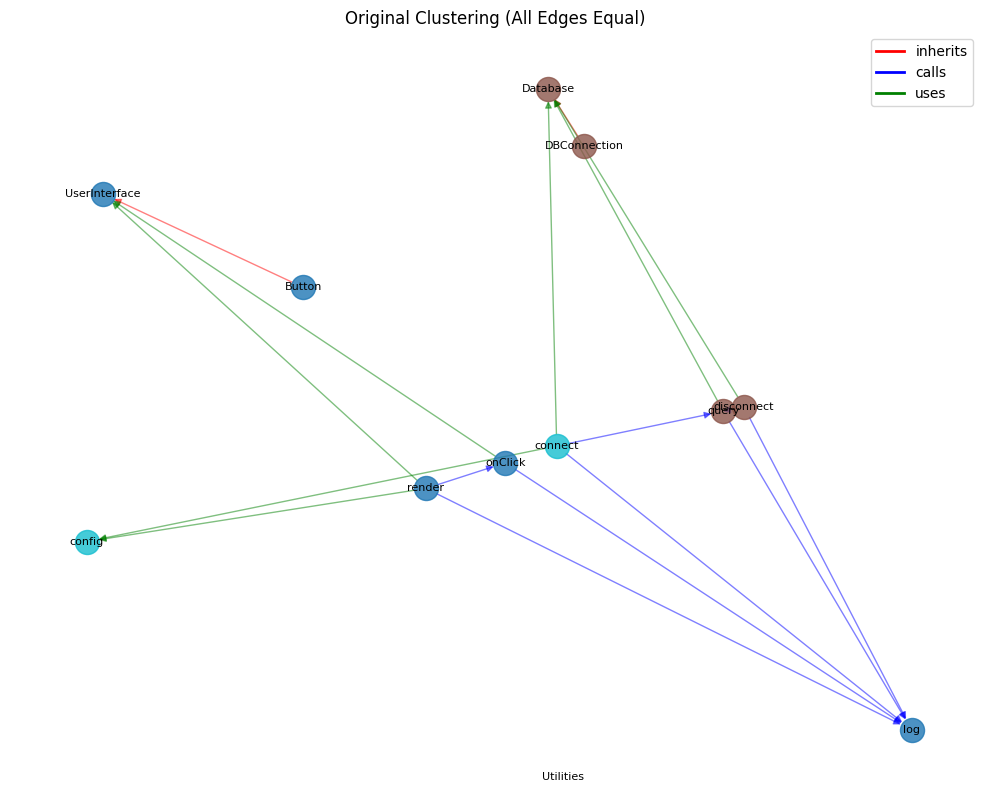

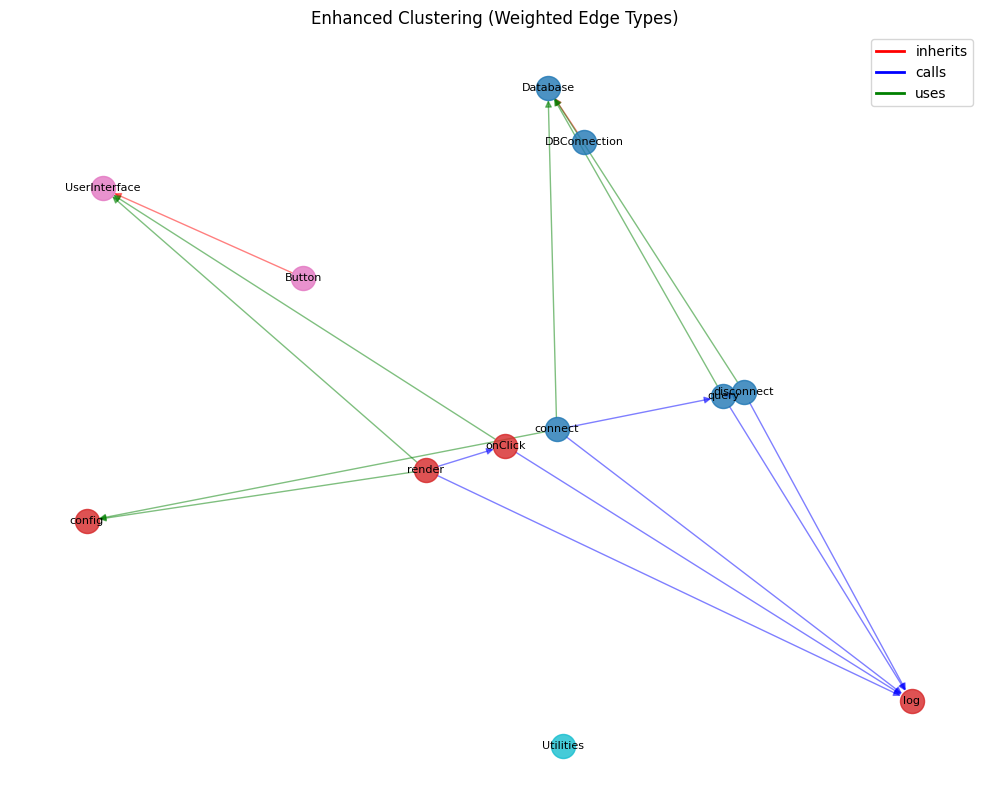

In [14]:
# Demonstration of enhanced edge types with a simple example

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Create a toy graph that represents a simple codebase
def create_demo_graph():
    G = nx.DiGraph()
    
    # Add nodes representing different entity types
    # Subsystem A: Database access
    G.add_node("ClassDB", kind="class", type="compound", name="Database")
    G.add_node("ClassDBConn", kind="class", type="compound", name="DBConnection") 
    G.add_node("FnConnect", kind="function", type="member", name="connect")
    G.add_node("FnQuery", kind="function", type="member", name="query")
    G.add_node("FnDisconnect", kind="function", type="member", name="disconnect")
    
    # Subsystem B: UI components
    G.add_node("ClassUI", kind="class", type="compound", name="UserInterface")
    G.add_node("ClassButton", kind="class", type="compound", name="Button")
    G.add_node("FnRender", kind="function", type="member", name="render")
    G.add_node("FnOnClick", kind="function", type="member", name="onClick")
    
    # Utilities
    G.add_node("Utils", kind="namespace", type="compound", name="Utilities")
    G.add_node("FnLog", kind="function", type="member", name="log")
    G.add_node("VarConfig", kind="variable", type="member", name="config")
    
    # Add edges with proper types
    # Inheritance relationships
    G.add_edge("ClassDBConn", "ClassDB", type="inherits")
    G.add_edge("ClassButton", "ClassUI", type="inherits")
    
    # Function calls within subsystems
    G.add_edge("FnConnect", "FnQuery", type="calls")
    G.add_edge("FnDisconnect", "FnQuery", type="calls")
    G.add_edge("FnRender", "FnOnClick", type="calls")
    
    # Usage relationships within subsystems
    G.add_edge("FnConnect", "ClassDB", type="uses") 
    G.add_edge("FnQuery", "ClassDB", type="uses")
    G.add_edge("FnDisconnect", "ClassDB", type="uses")
    G.add_edge("FnRender", "ClassUI", type="uses")
    G.add_edge("FnOnClick", "ClassUI", type="uses")
    
    # Utility usage across subsystems
    G.add_edge("FnConnect", "FnLog", type="calls")
    G.add_edge("FnQuery", "FnLog", type="calls") 
    G.add_edge("FnDisconnect", "FnLog", type="calls")
    G.add_edge("FnRender", "FnLog", type="calls")
    G.add_edge("FnOnClick", "FnLog", type="calls")
    G.add_edge("FnConnect", "VarConfig", type="uses")
    G.add_edge("FnRender", "VarConfig", type="uses")
    
    # For compatibility with existing code
    for u, v, data in list(G.edges(data=True)):
        if data["type"] not in ("inherits", "calls", "uses"):
            G[u][v]["type"] = "required_by"
    
    return G

# Create the demonstration graph
demo_graph = create_demo_graph()

# Define edge weights for different relationship types
edge_weights = {
    "inherits": 3.0,  # Strong structural relationship
    "calls": 2.0,     # Strong functional relationship
    "uses": 1.5,      # Medium relationship
    "required_by": 1.0 # Default weight
}

# Compare original vs. enhanced clustering
def compare_clustering(graph):
    # Original approach: Convert all edges to single type
    original_graph = graph.copy()
    for u, v in original_graph.edges():
        original_graph[u][v]["type"] = "required_by"
    
    # Create undirected graphs for clustering
    orig_undir = nx.Graph()
    for u, v, data in original_graph.edges(data=True):
        orig_undir.add_edge(u, v, weight=1.0)
    
    # Create enhanced graph with edge weights
    enhanced_undir = create_weighted_graph(graph, edge_weights)
    
    # Convert to igraph for clustering
    import igraph as ig
    import leidenalg as la
    
    # Helper function to convert networkx to igraph
    def nx_to_ig(g):
        nodes = list(g.nodes())
        node_map = {node: i for i, node in enumerate(nodes)}
        reverse_map = {i: node for node, i in node_map.items()}
        
        ig_graph = ig.Graph()
        ig_graph.add_vertices(len(node_map))
        
        edges = [(node_map[u], node_map[v]) for u, v in g.edges()]
        weights = [g[u][v].get("weight", 1.0) for u, v in g.edges()]
        
        ig_graph.add_edges(edges)
        ig_graph.es["weight"] = weights
        
        return ig_graph, reverse_map
    
    # Convert and cluster
    orig_ig, orig_map = nx_to_ig(orig_undir)
    enhanced_ig, enhanced_map = nx_to_ig(enhanced_undir)
    
    # Run clustering with identical parameters
    orig_partition = la.find_partition(
        orig_ig,
        la.RBConfigurationVertexPartition,
        weights="weight",
        resolution_parameter=1.0
    )
    
    enhanced_partition = la.find_partition(
        enhanced_ig,
        la.RBConfigurationVertexPartition,
        weights="weight",
        resolution_parameter=1.0
    )
    
    # Convert back to node IDs
    orig_clusters = {orig_map[i]: membership for i, membership in enumerate(orig_partition.membership)}
    enhanced_clusters = {enhanced_map[i]: membership for i, membership in enumerate(enhanced_partition.membership)}
    
    return orig_clusters, enhanced_clusters

# Run the comparison
orig_clusters, enhanced_clusters = compare_clustering(demo_graph)

# Visualize the results
def plot_clusters(graph, clusters, title):
    plt.figure(figsize=(10, 8))
    
    # Position nodes using spring layout
    pos = nx.spring_layout(graph, seed=42)
    
    # Get unique clusters for coloring
    unique_clusters = set(clusters.values())
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
    color_map = {cluster: colors[i] for i, cluster in enumerate(unique_clusters)}
    
    # Draw nodes colored by cluster
    for cluster_id in unique_clusters:
        node_list = [node for node in graph.nodes() if clusters.get(node) == cluster_id]
        nx.draw_networkx_nodes(
            graph, pos,
            nodelist=node_list,
            node_color=[color_map[cluster_id]],
            node_size=300,
            alpha=0.8
        )
    
    # Draw edges with colors based on type
    edge_colors = {
        "inherits": "red",
        "calls": "blue",
        "uses": "green",
        "required_by": "gray"
    }
    
    for edge_type in edge_colors:
        edge_list = [(u, v) for u, v, d in graph.edges(data=True) if d.get("type") == edge_type]
        nx.draw_networkx_edges(
            graph, pos,
            edgelist=edge_list,
            edge_color=edge_colors[edge_type],
            alpha=0.5,
            arrows=True
        )
    
    # Add node labels
    labels = {node: graph.nodes[node]["name"] for node in graph.nodes()}
    nx.draw_networkx_labels(graph, pos, labels, font_size=8)
    
    # Add legend for edge types
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=color, lw=2, label=edge_type)
        for edge_type, color in edge_colors.items()
        if any(d.get("type") == edge_type for _, _, d in graph.edges(data=True))
    ]
    plt.legend(handles=legend_elements, loc="upper right")
    
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot the two clustering results
plot_clusters(demo_graph, orig_clusters, "Original Clustering (All Edges Equal)")
plot_clusters(demo_graph, enhanced_clusters, "Enhanced Clustering (Weighted Edge Types)")

# Conclusion: Better Subsystem Discovery Through Enhanced Reference Types

## What We've Accomplished

1. **Analyzed Doxygen XML Structure**
   - Identified various reference types available in the XML
   - Categorized references based on their structural and usage significance
   - Determined which reference types are most valuable for subsystem identification

2. **Designed Enhanced Graph Construction**
   - Proposed specific edge types to differentiate relationships (CALLS, USES, INHERITS, etc.)
   - Created prototype code to classify references
   - Maintained backward compatibility with existing code

3. **Enhanced Structural Clustering**
   - Created a weighted graph approach that leverages edge type information
   - Maintained compatibility with existing algorithms (Leiden/Louvain)
   - Demonstrated potential improvements with a simple example

## Next Steps

1. **Implementation Phase**
   - Update the Doxygen parser to capture reference types
   - Modify the graph builder to use specialized edge types
   - Enhance the clustering algorithm to leverage edge weights
   - Create visualizations to validate the improvements

2. **Integration with Other Clustering Methods**
   - Apply insights to usage-based clustering
   - Update integrated clustering approaches
   - Develop new metrics that account for edge types

3. **Validation and Tuning**
   - Test against known subsystems in the codebase
   - Fine-tune edge weights based on empirical results
   - Validate against human expert classification

By implementing these changes, we expect to significantly improve the quality of subsystem discovery, particularly for complex codebases where different types of relationships have varying levels of significance for structural understanding.

In [ ]:
from collections import Counter
import re

# Count paths by tag type to identify reference relationships
reference_paths = {}
tag_counts = Counter()

for path in paths:
    if path[-1] not in refid_tags:
        continue
    
    tag = path[-1]
    tag_counts[tag] += 1
    
    # Extract the full context path (what contains the reference)
    path_str = '|'.join(n for n in path)
    
    # Find the compound or member that contains this reference
    context = None
    for i, p in enumerate(path):
        if p.startswith('compounddef') or p.startswith('memberdef'):
            if i < len(path) - 1:  # Not the last element
                context = p
    
    if context:
        reference_paths.setdefault(tag, {}).setdefault(context, []).append(path_str)

print("=== Reference Tag Counts ===")
for tag, count in sorted(tag_counts.items(), key=lambda x: -x[1]):
    print(f"{tag}: {count}")

print("\n=== Reference Context Patterns ===")
for tag, contexts in sorted(reference_paths.items()):
    print(f"\n{tag} references appear in:")
    for context_type, examples in sorted(contexts.items()):
        print(f"  - {context_type}: {len(examples)} occurrences")
        # Show a few examples for each context
        for ex in examples[:2]:  # Show just 2 examples per context
            print(f"      {ex}")
        if len(examples) > 2:
            print(f"      ... and {len(examples)-2} more")

In [5]:
path_strings = set(('|'.join(n for n in path) for path in paths))
reduced_path_strings = set()
for path in path_strings:
    for opath in path_strings:
        if opath.startswith(path + '|') and opath != path:
            break
    else:
        reduced_path_strings.add(path)


for p in sorted(reduced_path_strings): #, key=lambda x: (x.count('|'), x)):
    print(p)

compounddef[kind=class]|basecompoundref
compounddef[kind=class]|briefdescription
compounddef[kind=class]|compoundname
compounddef[kind=class]|derivedcompoundref
compounddef[kind=class]|detaileddescription
compounddef[kind=class]|includes
compounddef[kind=class]|innerclass
compounddef[kind=class]|location
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|briefdescription
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|detaileddescription
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|enumvalue|briefdescription
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|enumvalue|detaileddescription
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|enumvalue|initializer
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|enumvalue|name
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|inbodydescription
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|location
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|name
compounddef[kind=class]|sec

In [179]:
for p in path_strings:
    print(p)

compounddef[kind=file]|sectiondef|memberdef[kind=typedef]|inbodydescription
compounddef[kind=file]|sectiondef|memberdef[kind=typedef]|type|ref
compounddef[kind=struct]|sectiondef|memberdef[kind=friend]|detaileddescription
compounddef[kind=file]|sectiondef|memberdef[kind=variable]|definition
compounddef[kind=namespace]|sectiondef|memberdef[kind=function]|detaileddescription
compounddef[kind=file]|sectiondef|memberdef[kind=enum]|enumvalue|detaileddescription
compounddef[kind=dir]|compoundname
compounddef[kind=file]|sectiondef|memberdef[kind=variable]|detaileddescription|para|ndash
compounddef[kind=file]|sectiondef|memberdef[kind=function]|inbodydescription|para|ndash
compounddef[kind=struct]|sectiondef|memberdef[kind=friend]
compounddef[kind=namespace]|sectiondef|memberdef[kind=function]|briefdescription|para
compounddef[kind=file]|sectiondef|memberdef[kind=function]|references
compounddef[kind=namespace]|sectiondef|memberdef[kind=variable]|location
compounddef[kind=group]|sectiondef|mem

In [176]:
import re
from collections import defaultdict
from pprint import pprint
from typing import List, Dict, Set, Tuple

# Example input list: full XML paths, one per line
lines: List[str] = path_strings

# Define which compound and member variants we want to analyze
compound_variants = [
    'compounddef[kind=class]',
    'compounddef[kind=struct]',
    'compounddef[kind=file]',
    'compounddef[kind=namespace]',
    'compounddef[kind=dir]',
    'compounddef[kind=union]',
    'compounddef[kind=group]',
]

member_variants = [
    'memberdef[kind=function]',
    'memberdef[kind=variable]',
    'memberdef[kind=define]',
    'memberdef[kind=friend]',
    'memberdef[kind=typedef]',
    'memberdef[kind=enum]',
    '',  # For direct children of compounddef
]

# Step 1: Bucket each path by its compound + memberdef kind
path_buckets = defaultdict(set)

for line in lines:
    c_match = re.search(r'(compounddef\[kind=[^\]]+\])', line)
    if not c_match:
        continue  # Skip paths without compounddef
        
    compound = c_match.group(1)
    m_match = re.search(r'(memberdef\[kind=[^\]]+\])', line)
    
    if m_match:
        # Case 1: Path contains memberdef
        member = m_match.group(1)
        
        # Get path after memberdef for comparison
        parts = line.split('|')
        for i, part in enumerate(parts):
            if part.startswith('memberdef'):
                suffix = '|'.join(parts[i+1:]) if i+1 < len(parts) else ''
                key = (compound, member)
                path_buckets[key].add(suffix)
                break
    else:
        # Case 2: Path without memberdef (direct child of compounddef)
        member = ''  # Empty string for direct children
        
        # Get path after compounddef
        parts = line.split('|')
        for i, part in enumerate(parts):
            if part == compound:
                suffix = '|'.join(parts[i+1:]) if i+1 < len(parts) else ''
                if suffix:  # Only add non-empty suffixes
                    key = (compound, member)
                    path_buckets[key].add(suffix)
                break

# Step 2: Advanced analysis of path patterns
all_combinations = [(c, m) for c in compound_variants for m in member_variants]
all_paths = {
    (c, m): path_buckets.get((c, m), set()) for c, m in all_combinations
}

# Fields common across ALL combinations (base model fields)
all_sets = [s for s in all_paths.values() if s]
common_all = set.intersection(*all_sets) if all_sets else set()

# 2a. Fields common to all members within a specific compound type
compound_specific_common = {}
for c in compound_variants:
    member_sets = [all_paths[(c, m)] for m in member_variants if (c, m) in all_paths and all_paths[(c, m)]]
    if member_sets:
        compound_specific_common[c] = set.intersection(*member_sets) - common_all

# 2b. Fields common to all compounds for a specific member type
member_specific_common = {}
for m in member_variants:
    compound_sets = [all_paths[(c, m)] for c in compound_variants if (c, m) in all_paths and all_paths[(c, m)]]
    if compound_sets:
        member_specific_common[m] = set.intersection(*compound_sets) - common_all

# 3. Group similar compounds based on field patterns
compound_groups = defaultdict(set)
for path in path_buckets.values():
    # Find compounds that share this exact path set
    for c in compound_variants:
        member_path_sets = tuple(frozenset(all_paths.get((c, m), set())) for m in member_variants)
        compound_groups[member_path_sets].add(c)

# 4. Truly unique fields for each compound+member combination
unique_fields = {}
for (c, m), paths in all_paths.items():
    if not paths:
        continue
        
    # Remove common fields at all levels
    unique = paths - common_all
    if c in compound_specific_common:
        unique -= compound_specific_common[c]
    if m in member_specific_common:
        unique -= member_specific_common[m]
        
    if unique:
        unique_fields[(c, m)] = unique

# Output results
print("\n=== Base Model Fields (Common to All) ===")
for p in sorted(common_all):
    print(f"  - {p}")

print("\n=== Compound-Specific Common Fields ===")
for c, fields in compound_specific_common.items():
    if fields:
        print(f"\n{c}:")
        for p in sorted(fields):
            print(f"  - {p}")

print("\n=== Member-Type-Specific Common Fields ===")
for m, fields in member_specific_common.items():
    if fields:
        m_name = m if m else "(Direct children)"
        print(f"\n{m_name}:")
        for p in sorted(fields):
            print(f"  - {p}")

print("\n=== Compound Groups with Similar Field Patterns ===")
for i, (_, compounds) in enumerate(compound_groups.items()):
    if len(compounds) > 1:
        print(f"\nGroup {i+1}: {', '.join(sorted(compounds))}")

print("\n=== Unique Fields per Combination ===")
for (c, m), fields in unique_fields.items():
    m_name = m if m else "(direct)"
    print(f"\n{c} + {m_name}:")
    for p in sorted(fields):
        print(f"  - {p}")


=== Base Model Fields (Common to All) ===
  - briefdescription
  - detaileddescription

=== Compound-Specific Common Fields ===

compounddef[kind=class]:
  - location

compounddef[kind=struct]:
  - location

compounddef[kind=file]:
  - location

compounddef[kind=namespace]:
  - location

compounddef[kind=dir]:
  - compoundname
  - innerdir
  - innerfile
  - location

=== Member-Type-Specific Common Fields ===

memberdef[kind=function]:
  - 
  - argsstring
  - definition
  - inbodydescription
  - location
  - name
  - param
  - param|declname
  - param|defname
  - param|type
  - param|type|ref
  - referencedby
  - references
  - type
  - type|ref

memberdef[kind=variable]:
  - 
  - argsstring
  - definition
  - inbodydescription
  - location
  - name
  - referencedby
  - type
  - type|ref

memberdef[kind=define]:
  - 
  - inbodydescription
  - initializer
  - location
  - name
  - referencedby

memberdef[kind=friend]:
  - 
  - argsstring
  - definition
  - inbodydescription
  - locatio

In [152]:
from collections import defaultdict
from pydantic import BaseModel, Field
from typing import Dict, Set, List, Tuple

# Assume root_structure and path_qualifier_values were built using your parser
# They must be in scope for this script to work

# Stores tag -> set of paths (compound/member kind-qualified)
tag_usage: Dict[str, Set[str]] = defaultdict(set)

# Flatten root_structure to extract all tags by compound/member kind path

def flatten_paths(d, parent_path=""):
    tags = {}
    if isinstance(d, dict):
        path = d.get('_path', parent_path)
        for k, v in d.items():
            if k == 'tags':
                child_tags = v
                for child_tag, child_data in child_tags.items():
                    tags.setdefault(path, set()).add(child_tag)
                    nested = flatten_paths(child_data, f"{path}|{child_tag}")
                    for pk, ptags in nested.items():
                        tags.setdefault(pk, set()).update(ptags)
    return tags

flat_paths = flatten_paths(root_structure)

# Map of qualifier path to tags seen there
qualified_paths: Dict[str, Set[str]] = defaultdict(set)
for path, tags in flat_paths.items():
    qualifier = path.split('|')[0]  # e.g., compounddef[kind=file]
    qualified_paths[qualifier].update(tags)

# Compute common and unique tags per compounddef or memberdef kind
kind_sets: Dict[str, Set[str]] = {}
for k in path_qualifier_values:
    tag_type, attr = k
    for kind_val in path_qualifier_values[k]:
        qualifier = f"{tag_type}[{attr}={kind_val}]"
        kind_sets[qualifier] = qualified_paths.get(qualifier, set())

# Compute common fields and unique fields
common_tags = defaultdict(set)
unique_tags = defaultdict(set)

all_kinds = list(kind_sets.keys())
for tag in set.union(*kind_sets.values()):
    appearances = [k for k in all_kinds if tag in kind_sets[k]]
    if len(appearances) == len(all_kinds):
        for k in all_kinds:
            common_tags[k].add(tag)
    elif len(appearances) == 1:
        unique_tags[appearances[0]].add(tag)

# Generate pydantic mixins for common fields
def to_field(tag_name):
    return f"    {tag_name}: Optional[Any] = Field(default=None)"

print("# Common Mixins")
for base_kind in ['compounddef', 'memberdef']:
    mixin_fields = set.intersection(*[
        tags for k, tags in kind_sets.items()
        if k.startswith(base_kind + '[')
    ])
    if mixin_fields:
        print(f"\nclass {base_kind.capitalize()}Mixin(BaseModel):")
        for tag in sorted(mixin_fields):
            print(to_field(tag))

# Now generate specific classes for each compounddef/memberdef kind
print("\n# Specific Compound/Member Classes")
for kind, tags in kind_sets.items():
    base = "CompounddefMixin" if kind.startswith('compounddef') else "MemberdefMixin"
    class_name = kind.replace('[', '_').replace(']', '').replace('=', '_').capitalize()
    print(f"\nclass {class_name}({base}):")
    for tag in sorted(tags - common_tags[kind]):
        print(to_field(tag))

# Common Mixins

# Specific Compound/Member Classes

class Compounddef_kind_group(CompounddefMixin):
    argsstring: Optional[Any] = Field(default=None)
    briefdescription: Optional[Any] = Field(default=None)
    computeroutput: Optional[Any] = Field(default=None)
    definition: Optional[Any] = Field(default=None)
    detaileddescription: Optional[Any] = Field(default=None)
    enumvalue: Optional[Any] = Field(default=None)
    inbodydescription: Optional[Any] = Field(default=None)
    initializer: Optional[Any] = Field(default=None)
    itemizedlist: Optional[Any] = Field(default=None)
    linebreak: Optional[Any] = Field(default=None)
    listitem: Optional[Any] = Field(default=None)
    location: Optional[Any] = Field(default=None)
    mdash: Optional[Any] = Field(default=None)
    member: Optional[Any] = Field(default=None)
    memberdef: Optional[Any] = Field(default=None)
    name: Optional[Any] = Field(default=None)
    ndash: Optional[Any] = Field(default=None)
    para: Opt

In [148]:
path_qualifier_values

{('compounddef', 'kind'): {'class',
  'dir',
  'file',
  'group',
  'namespace',
  'struct'},
 ('memberdef', 'kind'): {'define',
  'enum',
  'friend',
  'function',
  'typedef',
  'variable'}}

In [149]:
path_strings = set(('|'.join(n for n in path) for path in paths))
collapsed = set()
for path in path_strings:
    for opath in path_strings:
        if opath.startswith(path + '|') and opath != path:
            break
    else:
        collapsed.add(path)

for p in sorted(collapsed): #, key=lambda x: (x.count('|'), x)):
    print(p)

compounddef[kind=class]|basecompoundref
compounddef[kind=class]|briefdescription
compounddef[kind=class]|compoundname
compounddef[kind=class]|derivedcompoundref
compounddef[kind=class]|detaileddescription
compounddef[kind=class]|includes
compounddef[kind=class]|innerclass
compounddef[kind=class]|location
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|briefdescription
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|detaileddescription
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|enumvalue|briefdescription
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|enumvalue|detaileddescription
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|enumvalue|initializer
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|enumvalue|name
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|inbodydescription
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|location
compounddef[kind=class]|sectiondef|memberdef[kind=enum]|name
compounddef[kind=class]|sec

In [150]:
# assume tag names are unique, compile all possible attributes and child tags for each tag
tags = {}
def walk_structure(d, tag):
    tags.setdefault(tag, {}).update({k:v for k,v in d.items() if k not in ('tags', '_path')})

    if 'tags' in d:
        tags[tag]['tags'] = sorted(set(tags[tag].get('tags', [])) | set(d['tags'].keys()))
        for child_tag, child in d.get('tags', {}).items():
            walk_structure(child, child_tag)

walk_structure(root_structure, 'compounddef')
pprint(tags)

{'argsstring': {},
 'basecompoundref': {'prot': 'str', 'refid': 'str', 'virt': 'str'},
 'briefdescription': {'tags': ['para']},
 'collaborationgraph': {},
 'compounddef': {'abstract': 'str',
                 'id': 'str',
                 'kind': 'str',
                 'language': 'str',
                 'prot': 'str',
                 'tags': ['basecompoundref',
                          'briefdescription',
                          'collaborationgraph',
                          'compoundname',
                          'derivedcompoundref',
                          'detaileddescription',
                          'incdepgraph',
                          'includedby',
                          'includes',
                          'inheritancegraph',
                          'innerclass',
                          'innerdir',
                          'innerfile',
                          'innernamespace',
                          'invincdepgraph',
                          'list

In [151]:
from collections import defaultdict

# go through parent sets and consolidate if they have all the qualifiers
def condense_tags_by_qualifier(tag_group: Set[str]):
    condensed: Dict[str, Dict[str, Set[Any]]] = {}
    split_tags: List[Tuple[str, Dict[str, str]]] = []
    skip_qualifiers_for_tag: Dict[str, Set[str]] = {}

    for qualified_tag in tag_group:
        if '[' not in qualified_tag:
            split_tags.append((qualified_tag, {}))
            continue

        tag, qualifiers = qualified_tag.rstrip(']').split('[')
        qualifiers = dict(q.split('=') for q in qualifiers.split(','))
        split_tags.append((tag, qualifiers))

        for k, v in qualifiers.items():
            condensed.setdefault(tag, {}).setdefault(k, set()).add(v)

    for (tag, attrib), values in path_qualifier_values.items():
        if condensed.get(tag, {}).get(attrib) == values: # compare sets, if the parents have all values
            skip_qualifiers_for_tag.setdefault(tag, set()).add(attrib)

    for tag, qualifiers in split_tags:
        qualifiers = {k: v for k, v in qualifiers.items() if k not in skip_qualifiers_for_tag.get(tag, set())}
        if qualifiers:
            yield f"{tag}[{','.join(f'{k}={qualifiers[k]}' for k in path_qualifiers[tag] if k in qualifiers)}]"
        else:
            yield tag


# Map: child_tag_name → set of parent_tag_names
tag_parents = defaultdict(set)
max_tag_len = 0

for path in paths:
    for i in range(1, len(path)):  # skip 0th (root-only)
        parent_tag = path[i - 1]
        child_tag = path[i]
        max_tag_len = max([max_tag_len, len(parent_tag), len(child_tag)])
        tag_parents[child_tag].add(parent_tag)

condensed_tag_parents = {child: set(condense_tags_by_qualifier(parents)) for child, parents in tag_parents.items()}

parent_groups = defaultdict(set)
# Group tags by their parent tags
for child, parents in condensed_tag_parents.items():
    parent_groups[tuple(sorted(parents))].add(child)

print("Qualifiers:")
for (tag, attrib), values in path_qualifier_values.items():
    print(f"{tag}[{attrib}]: {', '.join(sorted(values))}")

print("\nTags grouped by parent tags:\n")
print(f"{'  Parent Tags':<{max_tag_len}}   : Child Tags")
print(f"  {'-'*(max_tag_len+14)}")
for parents in sorted(parent_groups.keys(), key=len, reverse=True):
    children = parent_groups[parents]
    print(f"{'\n'.join(f'  {p:<{max_tag_len}}' for p in parents)} : {', '.join(sorted(children))}")

# Find tags that appear under multiple parent tags
print("\nTags with multiple parent tags:\n")
print(f"{'  Child Tag':<{max_tag_len}}   : Parent Tags")
print(f"  {'-'*(max_tag_len+14)}")
for tag, parents in sorted(condensed_tag_parents.items()):
    if len(parents) > 1:
        print(f"  {tag:<{max_tag_len}} : {', '.join(sorted(parents))}")

# Print each tag and its unique child tags (i.e., child tags that only appear under this parent)
print("\nTags with unique child tags:\n")
print(f"{'  Child Tag':<{max_tag_len}}   : Parent Tags")
print(f"  {'-'*(max_tag_len+14)}")
for tag in sorted(tags):
    # Find child tags for this tag
    child_tags = set(tags[tag].get('tags', []))
    unique_children = []
    for child in child_tags:
        if len(tag_parents[child]) == 1 and tag in tag_parents[child]:
            unique_children.append(child)
    if unique_children:
        print(f"  {tag:<{max_tag_len}} : {', '.join(sorted(unique_children))}")

Qualifiers:
compounddef[kind]: class, dir, file, group, namespace, struct
memberdef[kind]: define, enum, friend, function, typedef, variable

Tags grouped by parent tags:

  Parent Tags                 : Child Tags
  -----------------------------------------
  memberdef[kind=enum]       
  memberdef[kind=friend]     
  memberdef[kind=function]   
  memberdef[kind=typedef]    
  memberdef[kind=variable]   
  param                       : type
  compounddef[kind=class]    
  compounddef[kind=dir]      
  compounddef[kind=file]     
  compounddef[kind=namespace]
  compounddef[kind=struct]   
  memberdef                   : location
  compounddef[kind=class]    
  compounddef[kind=file]     
  compounddef[kind=group]    
  compounddef[kind=namespace]
  compounddef[kind=struct]    : sectiondef
  memberdef[kind=enum]       
  memberdef[kind=friend]     
  memberdef[kind=function]   
  memberdef[kind=typedef]    
  memberdef[kind=variable]    : qualifiedname
  briefdescription           
  de

In [132]:
from collections import defaultdict

# Map from suffix (child path) to list of parent prefixes
suffix_to_parents = defaultdict(set)

for path in paths:
    for i in range(1, len(path)):  # Split at all possible positions
        parent = path[:i]
        suffix = path[i:]
        if suffix:  # Skip empty suffixes
            suffix_to_parents[suffix].add(parent)

# Print common suffixes with multiple distinct parents
for suffix, parents in suffix_to_parents.items():
    if len(parents) > 1:
        print(f"Shared subtree: {suffix}")
        for p in sorted(parents):
            print(f"  Parent: {p}")


Shared subtree: ('sectiondef', 'memberdef[kind=define]', 'inbodydescription')
  Parent: ('compounddef[kind=file]',)
  Parent: ('compounddef[kind=group]',)
Shared subtree: ('memberdef[kind=define]', 'inbodydescription')
  Parent: ('compounddef[kind=file]', 'sectiondef')
  Parent: ('compounddef[kind=group]', 'sectiondef')
Shared subtree: ('inbodydescription',)
  Parent: ('compounddef[kind=class]', 'sectiondef', 'memberdef[kind=enum]')
  Parent: ('compounddef[kind=class]', 'sectiondef', 'memberdef[kind=friend]')
  Parent: ('compounddef[kind=class]', 'sectiondef', 'memberdef[kind=function]')
  Parent: ('compounddef[kind=class]', 'sectiondef', 'memberdef[kind=variable]')
  Parent: ('compounddef[kind=file]', 'sectiondef', 'memberdef[kind=define]')
  Parent: ('compounddef[kind=file]', 'sectiondef', 'memberdef[kind=enum]')
  Parent: ('compounddef[kind=file]', 'sectiondef', 'memberdef[kind=function]')
  Parent: ('compounddef[kind=file]', 'sectiondef', 'memberdef[kind=typedef]')
  Parent: ('comp